# P01：训练 VAE 编码器

在合成的 64x64 RGB 图像上训练一个紧凑的卷积变分自编码器（VAE）。编码器学习一个 32 维的潜在空间，P02 将其复用为观测编码器。此处的目标不是生成逼真的图像，而是学习一个稳定的潜在空间，供下游 notebook 使用。

**输出**：本 notebook 从头训练（无需任何预置权重文件），并将训练好的权重保存至 `vae_encoder.pt`，P02 和 P03 将以此作为观测编码器加载。

**内容大纲：**
1. 准备：合成数据与 DataLoader
2. 模型：编码器、解码器与重参数化
3. ELBO 损失：重建损失加 KL 散度
4. 训练：30 轮训练与损失曲线
5. 检验：重建效果、潜在遍历与随机采样

> Notebook 源文件: [p01_vae_encoder.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/zh/projects/p01_vae_encoder.ipynb)

In [1]:
%%bash
# 在全新环境中安装依赖。
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 准备

生成合成的彩色形状图像，使 notebook 无需任何外部下载即可离线运行。

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 让 Colab 和新环境优先使用支持中文的字体，避免标题和坐标轴显示成方框。
def _configure_cjk_font():
    preferred = [
        "Noto Sans CJK SC",
        "Noto Sans SC",
        "Source Han Sans SC",
        "Microsoft YaHei",
        "SimHei",
        "PingFang SC",
        "WenQuanYi Micro Hei",
    ]
    for family in preferred:
        try:
            font_manager.findfont(family, fallback_to_default=False)
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [family] + [f for f in mpl.rcParams.get("font.sans-serif", []) if f != family]
            mpl.rcParams["axes.unicode_minus"] = False
            return family
        except Exception:
            pass

    font_path = Path.home() / ".cache" / "notebook-fonts" / "NotoSansCJKsc-Regular.otf"
    if not font_path.exists():
        try:
            import urllib.request
            font_path.parent.mkdir(parents=True, exist_ok=True)
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
            urllib.request.urlretrieve(url, font_path)
        except Exception:
            font_path = None

    if font_path and font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        family = font_manager.FontProperties(fname=str(font_path)).get_name()
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [family] + [f for f in preferred if f != family]
        mpl.rcParams["axes.unicode_minus"] = False
        return family

    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    mpl.rcParams["axes.unicode_minus"] = False
    return None

_CJK_FONT = _configure_cjk_font()

torch.manual_seed(42)
np.random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
IS_ROCM = USE_CUDA and torch.version.hip is not None
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

# CUDA 可用时使用更快的计算内核。
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    if not IS_ROCM:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

print(f'使用设备       : {DEVICE}')
if USE_TPU:
    print('TPU 后端       : torch_xla')
elif USE_CUDA:
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    if IS_ROCM:
        print(f'ROCm/HIP       : {torch.version.hip}')
        print(f'GPU arch       : {torch.cuda.get_device_properties(0).gcnArchName}')
    else:
        print(f'CUDA 计算能力  : {torch.cuda.get_device_capability(0)}')
print(f'PyTorch 版本   : {torch.__version__}')

使用设备       : cuda
GPU            : NVIDIA L4
CUDA 计算能力  : (8, 9)
PyTorch 版本   : 2.11.0+cu128


运行环境已经准备好，先生成一个合成形状数据集，让 VAE 在没有外部下载的情况下完成训练。

数据集大小     : 10000
图像形状       : torch.Size([3, 64, 64])  (C, H, W)
每轮批次数     : 157


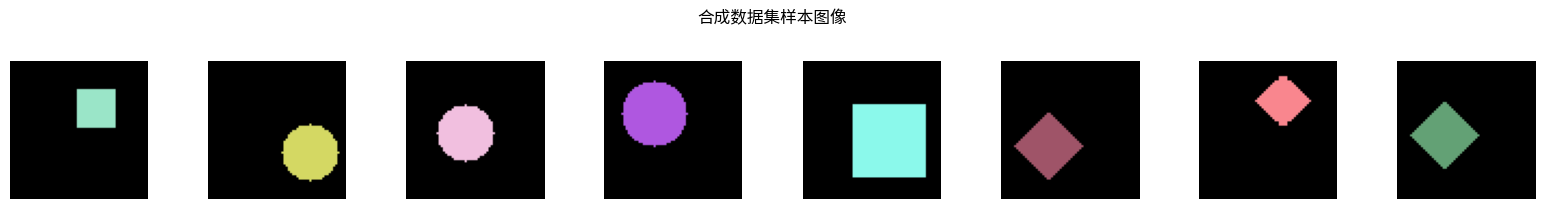

In [4]:
def make_shape_image(img_size=64, rng=None):
    """生成一张包含随机彩色形状的 64x64 RGB 图像。"""
    if rng is None:
        rng = np.random.default_rng()
    img = np.zeros((img_size, img_size, 3), dtype=np.float32)

    shape_type = rng.integers(0, 3)
    color = rng.uniform(0.3, 1.0, size=3).astype(np.float32)

    cx = rng.integers(16, img_size - 16)
    cy = rng.integers(16, img_size - 16)
    r  = rng.integers(8, 20)

    if shape_type == 0:
        x0, x1 = max(0, cx - r), min(img_size, cx + r)
        y0, y1 = max(0, cy - r), min(img_size, cy + r)
        img[y0:y1, x0:x1] = color
    elif shape_type == 1:
        ys, xs = np.mgrid[0:img_size, 0:img_size]
        mask = (xs - cx) ** 2 + (ys - cy) ** 2 <= r ** 2
        img[mask] = color
    else:
        for row in range(img_size):
            half_w = int(r * (1 - abs(row - cy) / max(r, 1)))
            if half_w > 0:
                c0 = max(0, cx - half_w)
                c1 = min(img_size, cx + half_w)
                img[row, c0:c1] = color

    return torch.from_numpy(img.transpose(2, 0, 1))


class ShapeDataset(Dataset):
    def __init__(self, n_samples=1000, img_size=64, seed=42):
        torch.manual_seed(seed)
        rng = np.random.default_rng(seed)
        # 将数据集存储为一个张量，以便高效索引。
        self.images = torch.stack([make_shape_image(img_size, rng) for _ in range(n_samples)])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


dataset = ShapeDataset(n_samples=10000)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2 if USE_CUDA else 0,
    pin_memory=USE_CUDA,
)

print(f'数据集大小     : {len(dataset)}')
print(f'图像形状       : {dataset[0].shape}  (C, H, W)')
print(f'每轮批次数     : {len(dataloader)}')

# 健全性检查：显示几张样本图像。
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(dataset[i].permute(1, 2, 0).numpy())
    ax.axis('off')
fig.suptitle('合成数据集样本图像', y=1.02)
plt.tight_layout()
plt.show()

## 2. 模型：编码器

`Encoder` 就是 [L02 观测编码](../lectures/lecture-02-encode-and-dynamics/01-encoding) 里讲的 CNN：四层步幅为 2 的卷积每次把空间分辨率减半（64 -> 32 -> 16 -> 8 -> 4），最终特征图是 `256 x 4 x 4`。展平后经过两个线性层，分别输出 `mu` 和 `log_var`，对应该页引入的近似后验 $q(z \mid x)$ 的均值和对数方差。之所以预测 `log_var` 而不是直接预测 `var` 或 `sigma`，是因为这样网络的原始输出可以是任意实数，后面取指数就能保证方差恒为正，不需要额外的约束激活函数。

In [5]:
# LATENT_DIM = 32
LATENT_DIM = 128
IMG_SIZE   = 64
IMG_CH     = 3


class Encoder(nn.Module):
    """将 3x64x64 图像编码为潜在均值和对数方差。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(IMG_CH, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.flat_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(start_dim=1)
        return self.fc_mu(h), self.fc_log_var(h)

class EncoderL6(nn.Module):
    """将 3x64x64 图像编码为潜在均值和对数方差。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(IMG_CH, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
        )
        self.flat_dim = 512 * 2 * 2
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(start_dim=1)
        return self.fc_mu(h), self.fc_log_var(h)



`Decoder` 与编码器对称，用转置卷积（讲义里"转置卷积"深挖框讲过）把空间分辨率逐次翻倍，撤销编码器的压缩过程：`4 -> 8 -> 16 -> 32 -> 64`。最后的 `Sigmoid` 把输出像素限制在 `[0, 1]`，与合成图像的生成方式一致。

In [6]:
class Decoder(nn.Module):
    """将潜在向量解码回 3x64x64 图像。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.flat_dim = 256 * 4 * 4
        self.fc = nn.Linear(latent_dim, self.flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, IMG_CH, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.deconv(h)

class DecoderL6(nn.Module):
    """将潜在向量解码回 3x64x64 图像。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.flat_dim = 512 * 2 * 2
        self.fc = nn.Linear(latent_dim, self.flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, IMG_CH, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 512, 2, 2)
        return self.deconv(h)


`VAE` 把编码器和解码器组合起来。`reparameterize` 就是讲义里的重参数化技巧，`z = mu + sigma * epsilon`，用 `std = exp(0.5 * log_var)` 实现，因为 `log_var = log(sigma^2)`，所以 `0.5 * log_var = log(sigma)`，取指数就还原出 `sigma`。`torch.randn_like(std)` 独立于网络参数采样出 `epsilon ~ N(0, I)`，这正是让这个操作保持可微的关键：梯度流过 `mu` 和 `std`，永远不流过随机采样本身。

In [7]:
class VAE(nn.Module):
    """结合编码器与解码器的变分自编码器。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        """采样 z = mu + sigma * epsilon。"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

    def encode(self, x):
        """返回潜在均值，不进行采样。"""
        mu, _ = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)


class VAEL6(nn.Module):
    """结合编码器与解码器的变分自编码器。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = EncoderL6(latent_dim)
        self.decoder = DecoderL6(latent_dim)

    def reparameterize(self, mu, log_var):
        """采样 z = mu + sigma * epsilon。"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

    def encode(self, x):
        """返回潜在均值，不进行采样。"""
        mu, _ = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)

model = VAEL6(latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量       : {total_params:,}')

# 使用前向传播测试验证张量形状。
dummy = torch.zeros(4, IMG_CH, IMG_SIZE, IMG_SIZE).to(DEVICE)
recon_dummy, mu_dummy, lv_dummy = model(dummy)
print(f'输入形状       : {dummy.shape}')
print(f'mu 形状        : {mu_dummy.shape}')
print(f'log_var 形状   : {lv_dummy.shape}')
print(f'重建形状       : {recon_dummy.shape}')

总参数量       : 11,083,459
输入形状       : torch.Size([4, 3, 64, 64])
mu 形状        : torch.Size([4, 128])
log_var 形状   : torch.Size([4, 128])
重建形状       : torch.Size([4, 3, 64, 64])


**核对讲义里的手算例子**：讲义用 $\mu = 0.50$，$\sigma = 0.20$，$\varepsilon = 1.30$ 手算出 $z = 0.76$。下面用同样的数字跑一遍 `reparameterize`，确认代码和公式完全对得上。

In [8]:
demo_mu = torch.tensor([[0.50]])
demo_std = torch.tensor([[0.20]])
demo_eps = torch.tensor([[1.30]])
demo_z = demo_mu + demo_std * demo_eps
print(f'z = mu + std * eps = {demo_mu.item()} + {demo_std.item()} * {demo_eps.item()} = {demo_z.item():.2f}')
assert abs(demo_z.item() - 0.76) < 1e-6, '与讲义手算结果不一致'


z = mu + std * eps = 0.5 + 0.20000000298023224 * 1.2999999523162842 = 0.76


## 3. ELBO 损失

`elbo_loss` 实现的正是[讲义里推导的 ELBO 两项](../lectures/lecture-02-encode-and-dynamics/01-encoding#elbo-损失-两个目标的平衡)：

$$
\mathcal{L} = \underbrace{\mathbb{E}_{q(z|x)}[-\log p(x|z)]}_{\text{重建}} + \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{KL 散度}}
$$

**重建项。** `F.mse_loss(recon_x, x, reduction='mean')` 代替了 $-\log p(x \mid z)$。这个替换是标准做法，但值得说清楚原因：如果假设解码器输出的分布是以重建像素为中心、方差固定的高斯分布，那么 $-\log p(x \mid z)$ 化简后就是 `recon_x` 和 `x` 之间的平方误差（相差一个常数项），正好就是 MSE。所以用 MSE 不是图方便的近似，而是这个高斯假设下精确的负对数似然。

**KL 项的解析形式从哪来。** 对于两个高斯分布，$q(z \mid x) = \mathcal{N}(\mu, \sigma^2)$ 和标准正态先验 $p(z) = \mathcal{N}(0, 1)$，KL 散度有精确的解析形式（不需要蒙特卡洛采样），把 $D_{KL}(q \| p) = \int q(z) \log \frac{q(z)}{p(z)} \, dz$ 的定义代入高斯密度函数展开即可得到：

$$
D_{KL}\big(\mathcal{N}(\mu, \sigma^2) \,\|\, \mathcal{N}(0, 1)\big) = -\frac{1}{2}\left(1 + \log \sigma^2 - \mu^2 - \sigma^2\right)
$$

对全部 32 个潜在维度求和（假设各维度独立，联合 KL 就是各维度 KL 之和），正好得到代码里 `torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)` 这一项（取负、除以 2）。`log_var.exp()` 从 $\log \sigma^2$ 还原出 $\sigma^2$，和上面 `reparameterize` 里用的关系一致。

**为什么要对 KL 项做缩放。** 代码额外把 `kl_loss` 除以 `IMG_CH * IMG_SIZE * IMG_SIZE`（即 12,288，和[「为什么要压缩」](../lectures/lecture-02-encode-and-dynamics/01-encoding#为什么要压缩)里提到的像素数一致）。重建 MSE 本来就是对 12,288 个像素取平均，而 KL 只是对 32 个潜在维度求和，如果不缩放，KL 项会比重建项小几个数量级，训练时几乎不起作用。除以同样的像素数，就能让两项在应用 `kl_weight` 之前处于可比的量级。

下面的健全性检查在训练开始前跑一次前向传播，用来确认损失函数能正确执行、输出形状正确；这里打印出的 KL 损失应该接近 0，因为未训练的编码器的 `mu` 和 `log_var` 都在初始化附近的 `(0, 0)`，恰好接近标准正态先验，这只是巧合，不是学到的结果。

In [10]:
def elbo_loss(recon_x, x, mu, log_var, kl_weight=1.0):
    """
    ELBO 损失 = 重建损失 + KL 散度。

    返回值：
        total_loss : 标量张量（用于反向传播）
        recon_loss : 标量张量（用于日志记录）
        kl_loss    : 标量张量（用于日志记录）
    """
    # 均方重建误差。
    # recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    mask = (x > 0.05).float()
    weight = 1.0 + 5.0 * mask  # 前景权重放大 6 倍
    recon_loss = torch.mean(weight * (recon_x - x) ** 2)

    # 对角高斯后验的解析形式 KL 散度。
    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    )
    # 对 KL 进行缩放，使其与重建项量级相当。
    kl_loss = kl_loss / (IMG_CH * IMG_SIZE * IMG_SIZE)

    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss


# 健全性检查。
with torch.no_grad():
    sample_batch = dataset[:4].to(DEVICE)
    r, mu_, lv_ = model(sample_batch)
    total, recon, kl = elbo_loss(r, sample_batch, mu_, lv_)

print(f'初始总损失     : {total.item():.4f}')
print(f'初始重建损失   : {recon.item():.4f}')
print(f'初始 KL 损失   : {kl.item():.6f}')

初始总损失     : 0.2944
初始重建损失   : 0.2944
初始 KL 损失   : 0.000001


## 4. 训练循环

除了标准的 `EPOCHS`/`LR` 之外，这里有三个超参数值得注意：

- **`KL_WEIGHT = 3.0`** 是 β-VAE 里的 β 系数：把 KL 项乘以这个权重后再加到重建损失上。大于 1 的权重会把潜在分布往 $\mathcal{N}(0, I)$ 推得比朴素 ELBO 更紧，代价是重建清晰度会打一点折扣。这直接影响第 5 节：如果潜在空间没有充分接近标准正态，从 `z ~ N(0, I)` 采样再解码就会得到不连贯的图像，因为解码器训练时从没见过那个区域的点。代码里的注释解释了为什么这个数据集上选 3.0：因为 KL 项已经除以了像素数，权重给到 3 仍然不会明显影响重建质量，同时能显著收紧潜在分布。
- **混合精度**（`torch.amp.autocast`、`GradScaler`）在 CUDA 上用 float16 做前向传播来加速训练，`GradScaler` 在反向传播前对梯度做缩放，防止 float16 下溢。这是与 VAE 统计性质无关的标准训练加速手段；在 CPU 上或 `USE_CUDA` 为 `False` 时，`autocast` 和 scaler 都是空操作，训练照常以 float32 进行。
- **分别追踪 `recon_loss` 和 `kl_loss`**（而不只是它们的和）是让下一个 cell 的双轴图真正有诊断价值的原因：只看 KL 曲线就能发现**后验坍缩**（posterior collapse），这是一种失败模式，KL 项在训练早期就跌到接近 0，因为编码器学会了忽略输入，对每张图像都输出 $\mu \approx 0, \log\sigma^2 \approx 0$，正好匹配先验，却同时毁掉了重建这条路径。

> **📖 后验坍缩（Posterior Collapse）**：如果看到 `Recon` 在训练最初几轮就停在一个较高的值不再下降，而 `KL` 几乎为零，说明发生了后验坍缩：编码器"偷懒"直接输出接近先验的分布，不再依赖输入图像。常见原因是 `KL_WEIGHT` 设得太高，或者训练早期重建信号太弱。

训练预算和损失权重都已确定，下面把数据集接到 epoch 迭代器和 DataLoader 上，开始按 minibatch 做优化。

In [11]:
EPOCHS     = 500
# LR         = 1e-3
LR = 3e-4
# elbo_loss 中 KL 已按像素数平均，权重设为 1 以上可使潜在空间
# 更接近 N(0, I)（改善先验采样和潜在遍历效果），
# 在此简单数据上对重建质量的影响可以忽略不计。
KL_WEIGHT  = 3.0

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 混合精度可加速 CUDA 训练，在 CPU 上也能正常回退。
scaler = torch.amp.GradScaler('cuda', enabled=USE_CUDA)

history_recon = []
history_kl    = []

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_recon = 0.0
    epoch_kl    = 0.0
    n_batches   = 0

    kl_factor = min(1.0, epoch / 10.0)

    for batch in dataloader:
        batch = batch.to(DEVICE, non_blocking=USE_CUDA)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=USE_CUDA):
            recon_batch, mu, log_var = model(batch)
            loss, recon_loss, kl_loss = elbo_loss(
                recon_batch, batch, mu, log_var, kl_weight=KL_WEIGHT * kl_factor
            )

        scaler.scale(loss).backward()
        optimizer_step(optimizer, scaler)

        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()
        n_batches   += 1

    avg_recon = epoch_recon / n_batches
    avg_kl    = epoch_kl    / n_batches
    history_recon.append(avg_recon)
    history_kl.append(avg_kl)

    if epoch % 5 == 0 or epoch == 1:
        print(f'第 {epoch:3d}/{EPOCHS} 轮 | '
              f'重建: {avg_recon:.5f} | KL: {avg_kl:.6f}')

print('\n训练完成。')

第   1/500 轮 | 重建: 0.11955 | KL: 0.007315
第   5/500 轮 | 重建: 0.04208 | KL: 0.003634
第  10/500 轮 | 重建: 0.03857 | KL: 0.001798
第  15/500 轮 | 重建: 0.03646 | KL: 0.001476
第  20/500 轮 | 重建: 0.03554 | KL: 0.001377
第  25/500 轮 | 重建: 0.03483 | KL: 0.001277
第  30/500 轮 | 重建: 0.03435 | KL: 0.001267
第  35/500 轮 | 重建: 0.03346 | KL: 0.001232
第  40/500 轮 | 重建: 0.03261 | KL: 0.001158
第  45/500 轮 | 重建: 0.03204 | KL: 0.001146
第  50/500 轮 | 重建: 0.02881 | KL: 0.001172
第  55/500 轮 | 重建: 0.02674 | KL: 0.001202
第  60/500 轮 | 重建: 0.01886 | KL: 0.001495
第  65/500 轮 | 重建: 0.01730 | KL: 0.001524
第  70/500 轮 | 重建: 0.01484 | KL: 0.001446
第  75/500 轮 | 重建: 0.01705 | KL: 0.001370
第  80/500 轮 | 重建: 0.01461 | KL: 0.001385
第  85/500 轮 | 重建: 0.01415 | KL: 0.001384
第  90/500 轮 | 重建: 0.01444 | KL: 0.001402
第  95/500 轮 | 重建: 0.01308 | KL: 0.001399
第 100/500 轮 | 重建: 0.01294 | KL: 0.001405
第 105/500 轮 | 重建: 0.01299 | KL: 0.001414
第 110/500 轮 | 重建: 0.01299 | KL: 0.001397
第 115/500 轮 | 重建: 0.01217 | KL: 0.001411
第 120/500 轮 | 重建

训练结束后，把两个损失分量按 epoch 画出来。期望的形状：`重建损失`随着编码器-解码器学会压缩和还原合成形状而稳定下降，`KL 散度`应该更缓慢地下降，最终稳定在一个较小的正值，而不是坍缩为零。如果 KL 曲线在最初几轮就跌到零，那是上面说的后验坍缩的警示信号，不是训练提前收敛的好消息。

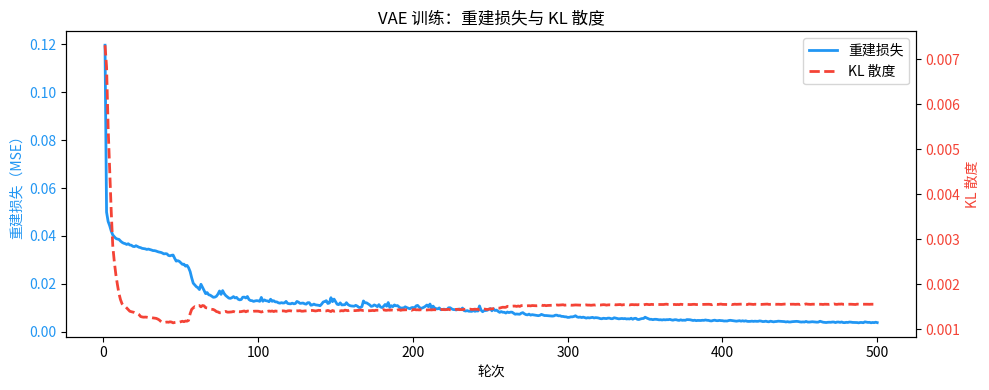

最终重建损失   : 0.00386
最终 KL 散度   : 0.001558


In [12]:
epochs_range = range(1, EPOCHS + 1)

fig, ax1 = plt.subplots(figsize=(10, 4))

color_recon = '#2196F3'
ax1.set_xlabel('轮次')
ax1.set_ylabel('重建损失（MSE）', color=color_recon)
ax1.plot(epochs_range, history_recon, color=color_recon, linewidth=2, label='重建损失')
ax1.tick_params(axis='y', labelcolor=color_recon)

ax2 = ax1.twinx()
color_kl = '#F44336'
ax2.set_ylabel('KL 散度', color=color_kl)
ax2.plot(epochs_range, history_kl, color=color_kl, linewidth=2, linestyle='--', label='KL 散度')
ax2.tick_params(axis='y', labelcolor=color_kl)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('VAE 训练：重建损失与 KL 散度')
fig.tight_layout()
plt.show()

print(f'最终重建损失   : {history_recon[-1]:.5f}')
print(f'最终 KL 散度   : {history_kl[-1]:.6f}')

损失曲线上的数字只能说明模型在优化某个目标，只有肉眼检查才能确认它优化对了。把保留批次的原始图像和重建图像放在一起比较：健康的编码器-解码器组合应该保留形状、颜色和大致位置，尽管 32 维的潜在瓶颈（相对于 12,288 维的输入像素）注定无法做到像素级的完美还原。

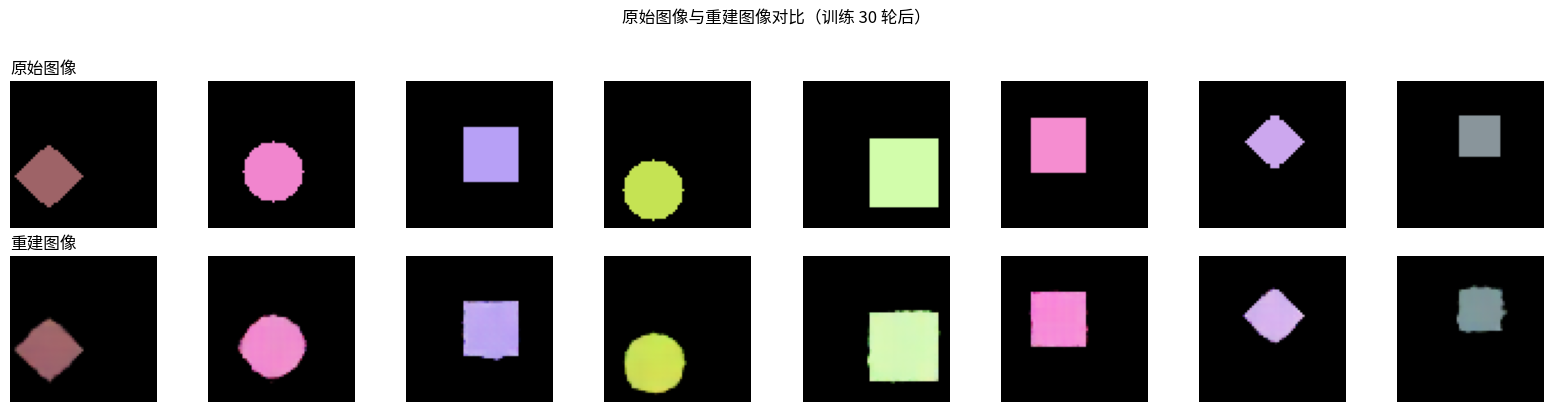

In [13]:
# 视觉对比：保留批次的原始图像与重建图像
model.eval()
with torch.no_grad():
    sample = dataset[200:208].to(DEVICE)
    recon, _, _ = model(sample)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    axes[0, i].imshow(sample[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')

axes[0, 0].set_title('原始图像', loc='left', fontsize=12)
axes[1, 0].set_title('重建图像', loc='left', fontsize=12)
plt.suptitle('原始图像与重建图像对比（训练 30 轮后）', y=1.02)
plt.tight_layout()
plt.show()

## 5. 潜在空间可视化

**潜在遍历（latent traversal）**。把 `z` 的所有维度固定为 0，只让其中一维从 -2 扫到 2，逐个解码，测试的正是 [VAE 直觉](../lectures/lecture-02-encode-and-dynamics/01-encoding#vae-直觉-学会压缩与重建)一节里说的**连续性**：潜在空间中相邻的点应该解码出视觉上相似的图像，`z` 平滑变化时不应该出现突变。这正是 KL 项的作用：如果没有它把后验拉向同一个密集分布的区域（$\mathcal{N}(0, I)$），编码器完全可以把不同图像散布到潜在空间里互不相连、形状随意的区域，在它们之间插值就可能经过解码出乱码的地带。

观察每个被扫描的维度是否只改变一个可辨识的属性（位置、大小或颜色），同时让其他属性大致不变。朴素的 ELBO 目标并不保证完美的**解耦**（每个维度都精确对应一个独立因素，这是 β-VAE、FactorVAE 等后续工作要解决的问题），所以在这个简单数据集上，维度 0-2 出现部分或混合的效果是预期之中的，不是 bug。

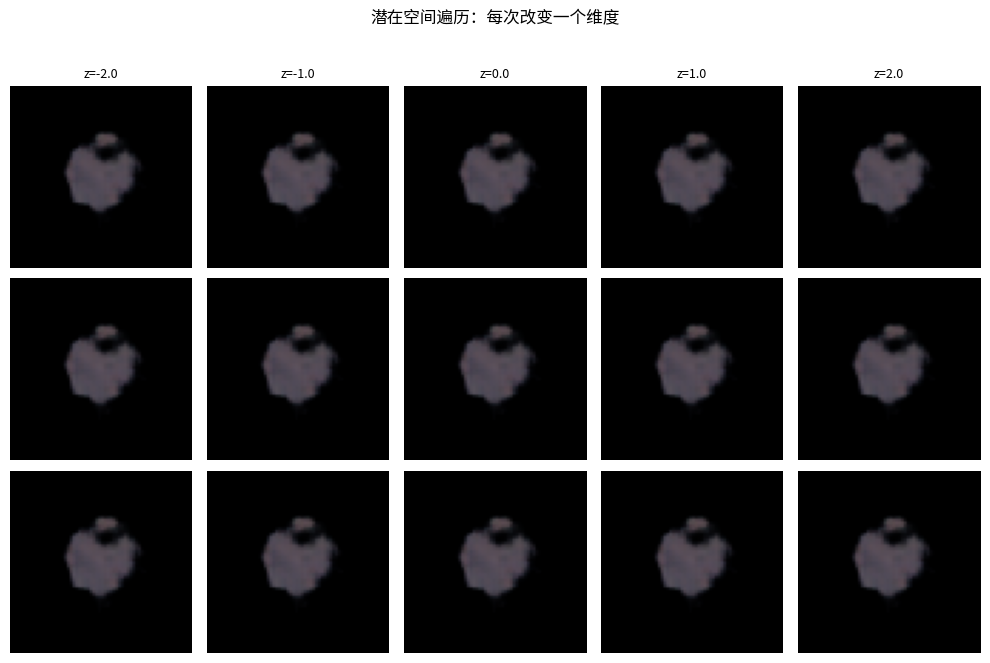

In [14]:
model.eval()

# 需要扫描的维度及扫描取值
dims_to_vary = [0, 1, 2]
sweep_values = np.linspace(-2, 2, 5)

n_rows = len(dims_to_vary)
n_cols = len(sweep_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2 + 0.5))

with torch.no_grad():
    for row_idx, dim in enumerate(dims_to_vary):
        for col_idx, val in enumerate(sweep_values):
            z = torch.zeros(1, LATENT_DIM, device=DEVICE)
            z[0, dim] = float(val)
            decoded = model.decode(z)  # 形状: (1, 3, 64, 64)
            img = decoded[0].cpu().permute(1, 2, 0).numpy()  # (64, 64, 3)

            ax = axes[row_idx, col_idx]
            ax.imshow(img)
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(f'维度 {dim}', fontsize=10, rotation=0, labelpad=30, va='center')

# 列标题
for col_idx, val in enumerate(sweep_values):
    axes[0, col_idx].set_title(f'z={val:.1f}', fontsize=9)

plt.suptitle('潜在空间遍历：每次改变一个维度', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**先验采样（prior sampling）**。这个 cell 完全绕开编码器，直接采样 `z ~ N(0, I)` 再解码。这是比上面的遍历更严格的检验：它检查的是**整个**训练后的潜在分布是否匹配标准正态先验，而不只是前面扫描过的三个维度。如果第 4 节的重建结果看起来不错，但这里的随机采样解码出来一团糟，说明编码器学到了对真实图像有效的压缩，但并没有让 $p(z) = \mathcal{N}(0, I)$ 在所有区域都成立，也就是说 KL 项相对重建项来说太弱了。直接的修法是调高 `KL_WEIGHT` 重新训练，代价是重建清晰度会下降；这种「重建 vs. 匹配先验」的张力正是第 3 节里介绍的那对目标的平衡。

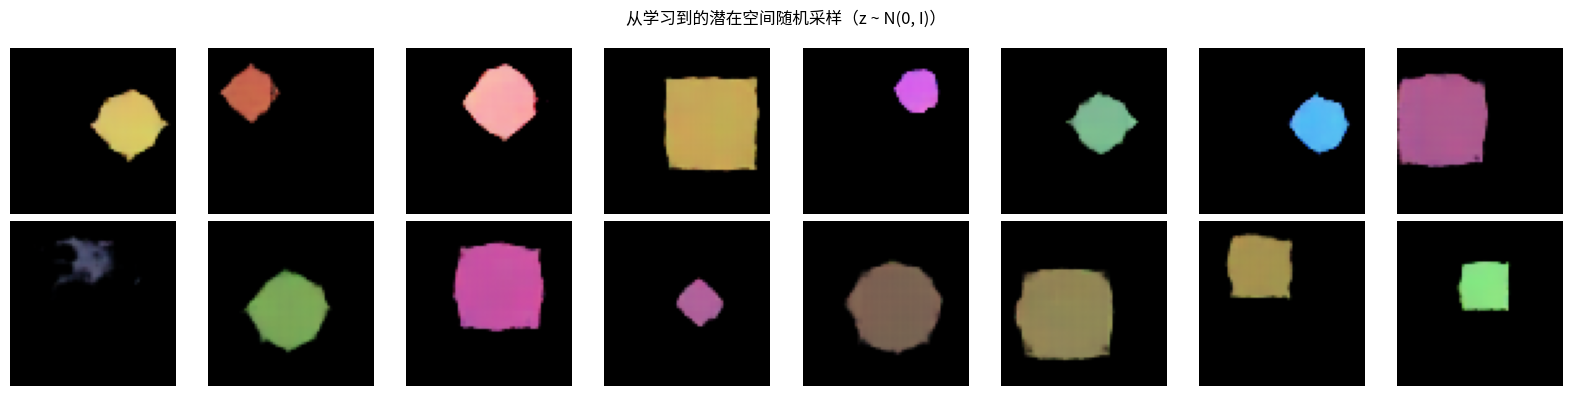

In [15]:
# 从学习到的先验中采样。
model.eval()
torch.manual_seed(42)

n_samples = 16
with torch.no_grad():
    z_random = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
    samples  = model.decode(z_random)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].cpu().permute(1, 2, 0).numpy())
    ax.axis('off')

plt.suptitle('从学习到的潜在空间随机采样（z ~ N(0, I)）', fontsize=12)
plt.tight_layout()
plt.show()

## 保存权重文件

将权重文件保存为 `vae_encoder.pt`，供 P02 和 P03 复用编码器权重。一次良好的训练应以较低的重建损失、视觉上连贯的重建结果，以及对解码形状有可预测影响的潜在遍历作为收尾。P02 通过 `model.encoder` 加载这份权重，把它当作一个冻结（不参与训练）的特征提取器：把每个原始观测 `o_t` 映射成潜在向量 `z_t`，动力学模型（GRU、MDN-RNN、RSSM）再学习预测它随时间的演化，这正是 [Dreamer 中编码器的桥梁作用](../lectures/lecture-02-encode-and-dynamics/03-dynamics-dreamer-series#dreamer-中编码器的桥梁作用) 里描述的编码器到动力学模型的交接。

In [ ]:
import os

checkpoint_path = '../../public/vae_encoder.pt'
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'encoder':          model.encoder.state_dict(),
    'decoder':          model.decoder.state_dict(),
    'latent_dim':       LATENT_DIM,
    'img_size':         IMG_SIZE,
    'img_channels':     IMG_CH,
    'final_recon_loss': history_recon[-1],
    'final_kl_loss':    history_kl[-1],
    'epochs_trained':   EPOCHS,
    'checkpoint_format': 'vae-v2',
}, checkpoint_path)

size_kb = os.path.getsize(checkpoint_path) / 1024
print(f'权重文件已保存至: {checkpoint_path}  ({size_kb:.1f} KB)')
print(f'潜在维度        : {LATENT_DIM}')
print(f'最终重建损失    : {history_recon[-1]:.5f}')
print(f'最终 KL 散度    : {history_kl[-1]:.6f}')
print()
print('在下游项目中加载的方法：')
print("  ckpt = torch.load('../../public/vae_encoder.pt', map_location='cpu')")
print("  model = VAE(latent_dim=ckpt['latent_dim'])")
print("  model.load_state_dict(ckpt['model_state_dict'])")

权重文件已保存至: vae_encoder.pt  (6954.4 KB)
潜在维度        : 32
最终重建损失    : 0.01238
最终 KL 散度    : 0.001310

在下游项目中加载的方法：
  ckpt = torch.load('vae_encoder.pt', map_location='cpu')
  model = VAE(latent_dim=ckpt['latent_dim'])
  model.load_state_dict(ckpt['model_state_dict'])


In [18]:
from google.colab import drive
import torch
import os

# 1. 挂载云端硬盘
drive.mount('/content/drive')

# 2. 保存到 Drive 目录
save_dir = '/content/drive/MyDrive/world_models/'
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, 'vae_encoder.pt')

torch.save({
    'model_state_dict': model.state_dict(),
    'encoder':          model.encoder.state_dict(),
    'decoder':          model.decoder.state_dict(),
    'latent_dim':       LATENT_DIM,
    'img_size':         IMG_SIZE,
    'img_channels':     IMG_CH,
    'final_recon_loss': history_recon[-1],
    'final_kl_loss':    history_kl[-1],
    'epochs_trained':   EPOCHS,
    'checkpoint_format': 'vae-v2',
}, checkpoint_path)

size_kb = os.path.getsize(checkpoint_path) / 1024
print(f'权重文件已保存至: {checkpoint_path}  ({size_kb:.1f} KB)')
print(f'潜在维度        : {LATENT_DIM}')
print(f'最终重建损失    : {history_recon[-1]:.5f}')
print(f'最终 KL 散度    : {history_kl[-1]:.6f}')
print()
print('在下游项目中加载的方法：')
print("  ckpt = torch.load('../../public/vae_encoder.pt', map_location='cpu')")
print("  model = VAE(latent_dim=ckpt['latent_dim'])")
print("  model.load_state_dict(ckpt['model_state_dict'])")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
权重文件已保存至: /content/drive/MyDrive/world_models/vae_encoder.pt  (43310.2 KB)
潜在维度        : 128
最终重建损失    : 0.00386
最终 KL 散度    : 0.001558

在下游项目中加载的方法：
  ckpt = torch.load('../../public/vae_encoder.pt', map_location='cpu')
  model = VAE(latent_dim=ckpt['latent_dim'])
  model.load_state_dict(ckpt['model_state_dict'])
